# GARBAGE CLASSIFICATION USING CNN

### 1. Import Library

In [2]:
import os
import torch
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

### 2. Dataset Preparation

#### 2.1 Check Dataset Folder

In [3]:
!dir TrashType_Image_Dataset\train

 Volume in drive C has no label.
 Volume Serial Number is A650-81C1

 Directory of c:\Users\Dell\Downloads\CNN_Trash Classification\TrashType_Image_Dataset\train

06/21/2026  05:54 PM    <DIR>          .
06/21/2026  05:54 PM    <DIR>          ..
06/21/2026  05:54 PM    <DIR>          cardboard
06/21/2026  05:54 PM    <DIR>          glass
06/21/2026  05:54 PM    <DIR>          metal
06/21/2026  05:54 PM    <DIR>          paper
06/21/2026  05:54 PM    <DIR>          plastic
06/21/2026  05:54 PM    <DIR>          trash
               0 File(s)              0 bytes
               8 Dir(s)   1,628,901,376 bytes free


In [4]:
!dir TrashType_Image_Dataset\train\cardboard

 Volume in drive C has no label.
 Volume Serial Number is A650-81C1

 Directory of c:\Users\Dell\Downloads\CNN_Trash Classification\TrashType_Image_Dataset\train\cardboard

06/21/2026  05:54 PM    <DIR>          .
06/21/2026  05:54 PM    <DIR>          ..
10/15/2023  04:51 PM            17,333 cardboard_001.jpg
10/15/2023  04:51 PM            18,110 cardboard_002.jpg
10/15/2023  04:51 PM            21,252 cardboard_003.jpg
10/15/2023  04:51 PM            18,932 cardboard_005.jpg
10/15/2023  04:51 PM            14,830 cardboard_006.jpg
10/15/2023  04:51 PM            20,160 cardboard_007.jpg
10/15/2023  04:51 PM            15,224 cardboard_008.jpg
10/15/2023  04:51 PM            19,281 cardboard_009.jpg
10/15/2023  04:51 PM            21,683 cardboard_010.jpg
10/15/2023  04:51 PM            20,452 cardboard_011.jpg
10/15/2023  04:51 PM            25,517 cardboard_012.jpg
10/15/2023  04:51 PM            11,967 cardboard_015.jpg
10/15/2023  04:51 PM            22,493 cardboard_018.jpg
10/

#### 2.2 Display Image from Dataset

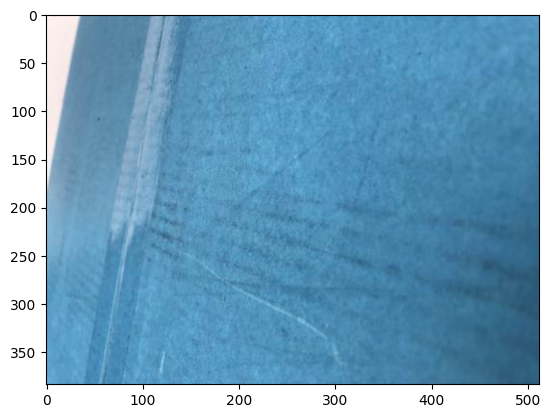

In [5]:
img = cv.imread("TrashType_Image_Dataset/train/cardboard/cardboard_009.jpg")
plt.imshow(img)

In [6]:
print(type(img))  # harus: <class 'numpy.ndarray'>
print(img.shape) 

<class 'numpy.ndarray'>
(384, 512, 3)


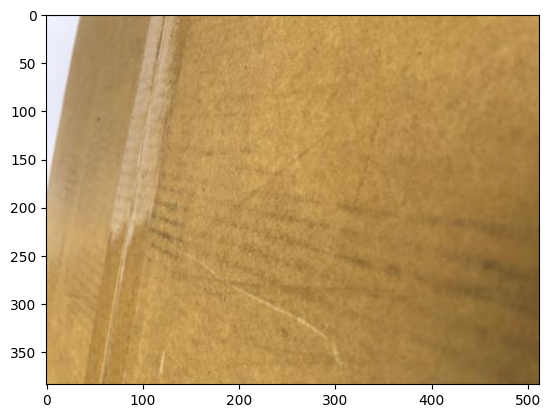

In [7]:
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img_rgb)

### 3. Transfer Learning

#### 3.1 Data Understanding

In [8]:
# Import Required Library

from torchvision import transforms, datasets

In [9]:
# Set Dataset Paths

train_dir = "TrashType_Image_Dataset/train"
val_dir = "TrashType_Image_Dataset/val"

In [10]:
# Initialize Dataset Container

image_dataset = {}

In [11]:
# Load Dataset with ImageFolder

image_dataset['train'] = datasets.ImageFolder(train_dir)
image_dataset['val'] = datasets.ImageFolder(val_dir)

In [12]:
# Verify the number of images in the training dataset

len(image_dataset['train'])

2019

In [13]:
# Verify the image specification in the train dataset

image_dataset['train'][2000]

(<PIL.Image.Image image mode=RGB size=512x384>, 5)

In [14]:
# Inspect a Sample from Dataset

image, label = image_dataset['train'][0]

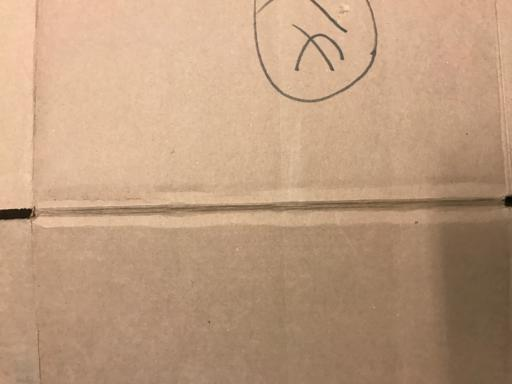

In [15]:
# Show the image
image

In [16]:
# show the class of the image
label

0

#### 3.2 Data Prepocessing

In [17]:
# Define the data transforms for training and validation datasets

data_transforms = transforms.Compose([transforms.Resize((224, 224)),
                                      transforms.ToTensor(), 
                                      transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

# resize ke 224x224, convert to tensor (0-1), and normalize the image

In [18]:
# Display the data transforms
data_transforms

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [19]:
# Load Dataset with ImageFolder and Apply Transforms

image_dataset['train'] = datasets.ImageFolder(train_dir, transform=data_transforms)
image_dataset['val'] = datasets.ImageFolder(val_dir, transform=data_transforms)

In [20]:
# Inspect a Sample from Dataset
img, label = image_dataset['train'][0]

In [21]:
# Show the image
img

tensor([[[ 2.0092,  2.0434,  2.0434,  ...,  1.5982,  1.5639,  1.5810],
         [ 2.0605,  2.0777,  2.0605,  ...,  1.5982,  1.5982,  1.5639],
         [ 2.0777,  2.0948,  2.0948,  ...,  1.5982,  1.6324,  1.5810],
         ...,
         [ 1.1187,  1.0673,  0.9988,  ..., -0.1828, -0.1657, -0.1314],
         [ 1.0844,  1.0844,  1.0159,  ..., -0.1828, -0.1657, -0.1486],
         [ 1.0673,  1.0331,  0.9988,  ..., -0.1657, -0.1657, -0.1486]],

        [[ 1.4832,  1.5182,  1.5182,  ...,  0.9930,  0.9580,  0.9755],
         [ 1.5357,  1.5532,  1.5357,  ...,  0.9930,  0.9930,  0.9580],
         [ 1.5532,  1.5707,  1.5707,  ...,  0.9930,  1.0280,  0.9755],
         ...,
         [ 0.5903,  0.5378,  0.4853,  ..., -0.4951, -0.4776, -0.4426],
         [ 0.5553,  0.5553,  0.5203,  ..., -0.4951, -0.4776, -0.4601],
         [ 0.5378,  0.5028,  0.5028,  ..., -0.4776, -0.4776, -0.4601]],

        [[ 1.0888,  1.1237,  1.1237,  ...,  0.7054,  0.6705,  0.6879],
         [ 1.1411,  1.1585,  1.1411,  ...,  0

In [22]:
# Map Label Index to Class Name
cat_dict = {0: 'cardboard', 1: 'glass', 2: 'metal', 3: 'paper', 4: 'plastic', 5: 'trash'}

In [23]:
# Define a function to show the image with its corresponding class name

def show_image(img, cat):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.title(cat_dict[cat])
    plt.imshow(img)

In [24]:
# Show the image with its corresponding class name
img, label = image_dataset['train'][0]

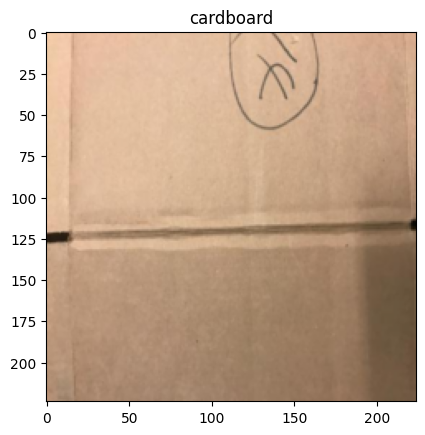

In [25]:
show_image(img, label)

### 4. Transfer Learning

In [26]:
# Import required libraries 
from torchvision import models

In [27]:
# define the model architecture and load the pretrained model

model = models.alexnet(pretrained=True)

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [28]:
# Display the model
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

#### 4.1 change output layer

kita perlu menyesuaikan pretrain model karena defaultnya AlexNet memiliki output 1000

In [29]:
# import required library
import torch.nn as nn

In [30]:
# Modify the classifier layer to match the number of classes in the dataset
model.classifier[6] = nn.Linear(4096, 6)

In [31]:
# inspect the modified model
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

#### 4.2 freeze some parameters

In [32]:
# disable feature extraction for the pretrained model
for param in model.features.parameters():
    param.requires_grad = False
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False


In [33]:
# inspect the classifier layer parameters to verify that they are trainable
for param in model.classifier.parameters():
        print(param.requires_grad)

True
True
True
True
True
True


#### 4.3 Define loss function

In [34]:
# Define the loss function
criterion = nn.CrossEntropyLoss()

#### 4.4 Define Optimizer

In [35]:
import torch.optim as optim

In [36]:
# Define the optimizer

optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [37]:
# Initialize the dataloaders dictionary
dataloaders = {}

In [38]:
# Load the training dataset into a DataLoader

dataloaders['train'] = torch.utils.data.DataLoader(image_dataset['train'], batch_size=4, shuffle=True, num_workers=4)

In [39]:
# Set Computing Device (GPU/CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# pindahkan model ke device (GPU/CPU) yang telah ditentukan
model.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

: 

#### 4.5 Training Process

In [ ]:
num_epochs = 10
list_loss = []
list_acc = []
for epoch in range(num_epochs):
    training_loss = 0.0
    training_accuracy = 0.0
    training_corrects = 0
    for inputs, labels in dataloaders['train']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model.forward(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        training_loss += loss.item() * inputs.size(0)
        training_corrects += torch.sum(preds == labels.data)

    epoch_loss = training_loss / len(image_dataset['train'])
    epoch_acc = training_corrects.double() / len(image_dataset['train'])

    list_loss.append(epoch_loss)
    list_acc.append(epoch_acc)

    print('Loss : {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

#### 4.6 Plot loss and acc from training result

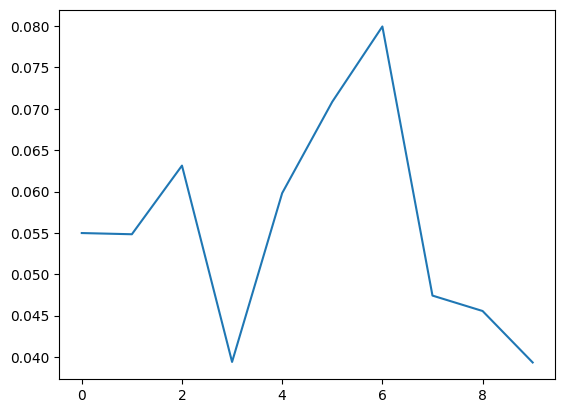

In [ ]:
plt.plot(list_loss)

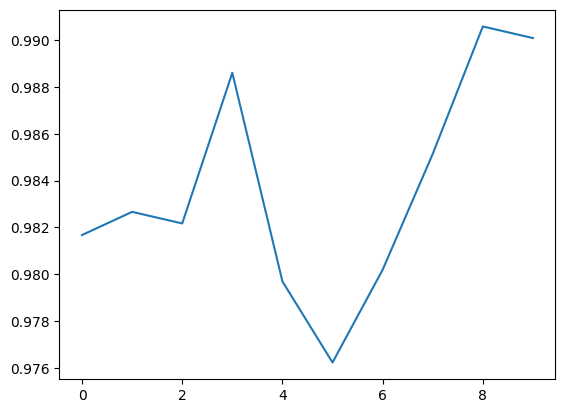

In [ ]:
plt.plot(list_acc)

### 5. Predict Validation Data

In [ ]:
# Load the validation dataset into a DataLoader
dataloaders['val'] = torch.utils.data.DataLoader(image_dataset['val'], batch_size=4, shuffle=True, num_workers=4)

In [ ]:
val_corrects = 0
for inputs, labels in dataloaders['val']:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = model.forward(inputs)
    _, preds = torch.max(outputs, 1)
    loss = criterion(outputs, labels)
    
    val_corrects += torch.sum(preds == labels.data)

In [ ]:
# Calculate the validation accuracy
acc = val_corrects.double() / len(image_dataset['val'])

In [ ]:
# Get the accuracy as a Python scalar
acc.item()

0.7913385826771654

### 6. Predict Single Image

In [ ]:
# import required library
from PIL import Image

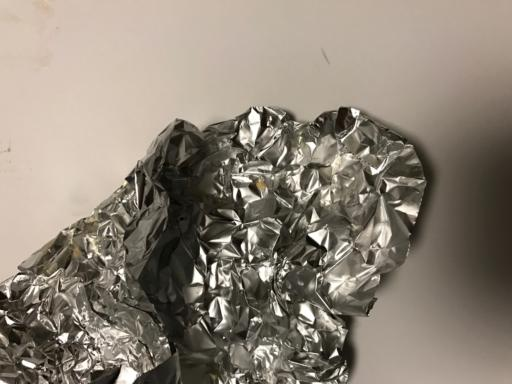

In [ ]:
# load single image for prediction
img = Image.open("TrashType_Image_Dataset/val/metal/metal_042.jpg")
img

In [ ]:
# apply image transforms dan convert to tensor
img_tensor = data_transforms(img).unsqueeze(0).to(device)

In [ ]:
# inspect the image tensor
img_tensor.shape

torch.Size([1, 3, 224, 224])

In [ ]:
# make prediction on the image tensor
outputs = model.forward(torch.reshape(img_tensor, (1, 3, 224, 224)))

In [ ]:
# inspect the output tensor
outputs.shape

torch.Size([1, 6])

In [ ]:
# get the predicted class index
outputs.argmax().item()

2